In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/Jamboree_Admission.csv')

In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.shape

(500, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


no null values are there

In [ ]:
df.drop('Serial No.', axis = 1, inplace = True)

In [ ]:
df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


GRE Score:  
Mean ≈ 316, Std ≈ 11 → most students lie between 305-328.  
Range: 290 (min) to 340 (max)

TOEFL Score:   
Mean ≈ 107, Std ≈ 6 → most students lie between 101-113.         
Range: 92-120

SOP (Statement of Purpose) and LOR (Letter of Recommendation): Median ≈ 3.5, Range = 1-5  

CGPA    
Mean ≈ 8.57, Std ≈ 0.60.   
Range: 6.8 (low) to 9.92        

In [ ]:
df['Research'].value_counts()

,count
Research,
1,280
0,220


In [ ]:
df[df['Research'] == 1].shape[0] *100 / df.shape[0]

56.0

56% stuents have research experience

In [ ]:
df.duplicated().any()

np.False_

no duplicate values are there.

In [ ]:
df.isnull().sum()

,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
df.rename(columns={"Chance of Admit ": "Chance of Admit"}, inplace=True)

<Axes: >

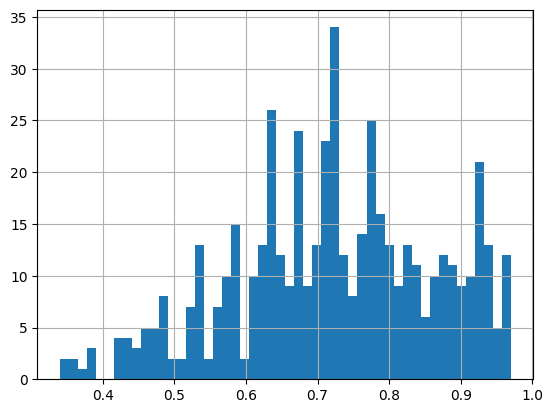

In [ ]:
df['Chance of Admit'].hist(bins = 50)

chance of admit varies from 0.34 to 0.97 .  
most of variation lies between 0.63 to 0.82.

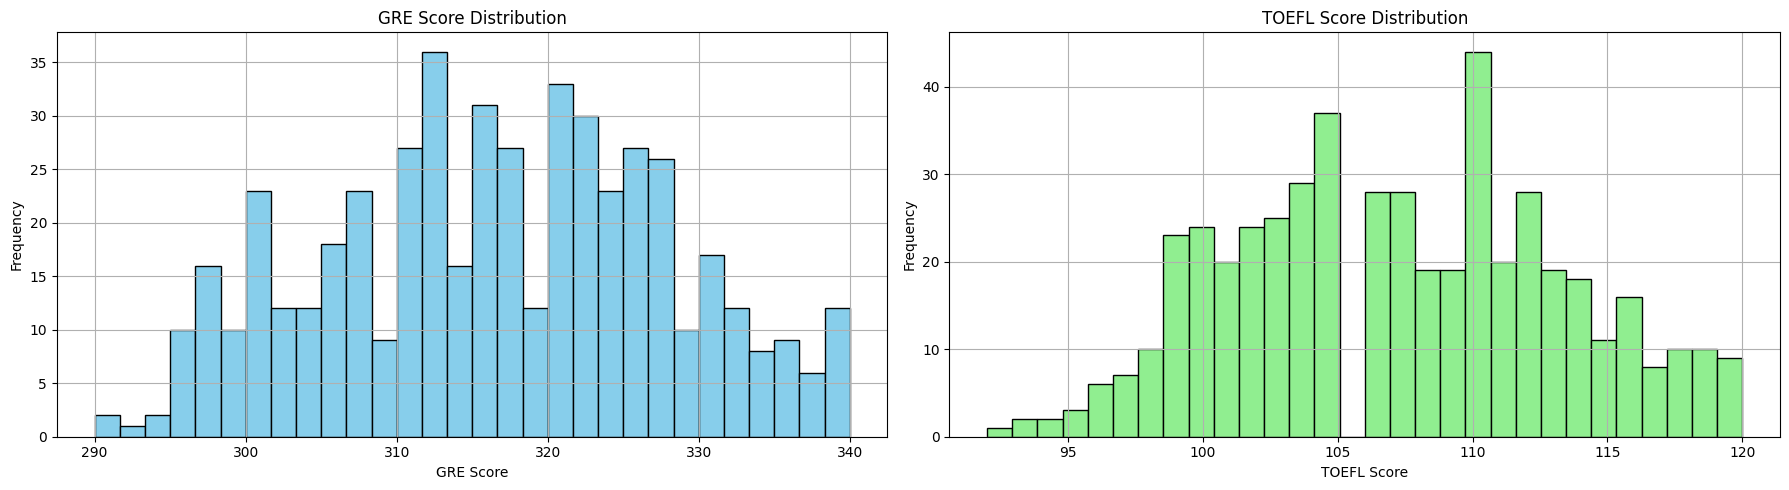

In [ ]:
plt.figure(figsize=(18,5))

# GRE Score
plt.subplot(1, 2, 1)
df['GRE Score'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("GRE Score Distribution")
plt.xlabel("GRE Score")
plt.ylabel("Frequency")

# TOEFL Score
plt.subplot(1, 2, 2)
df['TOEFL Score'].hist(bins=30, color='lightgreen', edgecolor='black')
plt.title("TOEFL Score Distribution")
plt.xlabel("TOEFL Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

both Gre scores and Toefl scores have almost symmetrical variation.

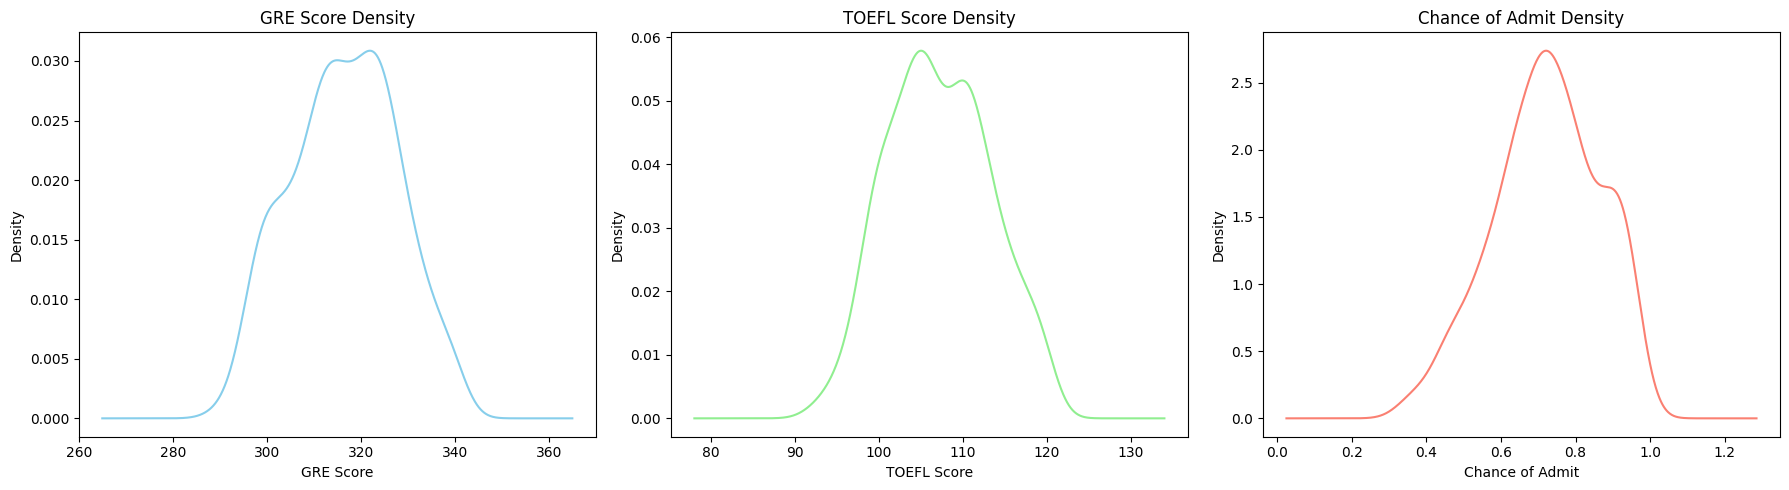

In [ ]:
plt.figure(figsize=(18,5))

# GRE Score density
plt.subplot(1, 3, 1)
df["GRE Score"].plot.density(color="skyblue")
plt.title("GRE Score Density")
plt.xlabel("GRE Score")

# TOEFL Score density
plt.subplot(1, 3, 2)
df["TOEFL Score"].plot.density(color="lightgreen")
plt.title("TOEFL Score Density")
plt.xlabel("TOEFL Score")

# Chance of Admit density
plt.subplot(1, 3, 3)
df["Chance of Admit"].plot.density(color="salmon")
plt.title("Chance of Admit Density")
plt.xlabel("Chance of Admit")

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns

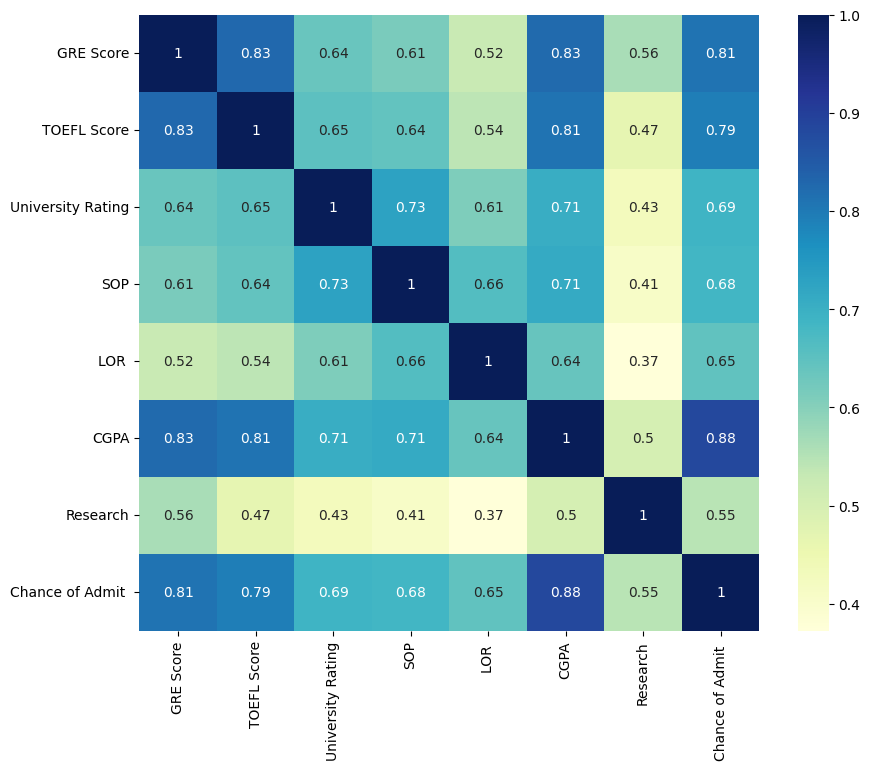

In [ ]:
plt.figure(figsize=(10,8))
ax = sns.heatmap(df.corr(), cmap="YlGnBu", annot=True)

as we can observe all the features have positive correlation with Target Variable.    
some features like CGPA, GRE Score, TOEFL Score have highest correlation with Chance of Admit. so they have more weightage in predicting Target variable.   

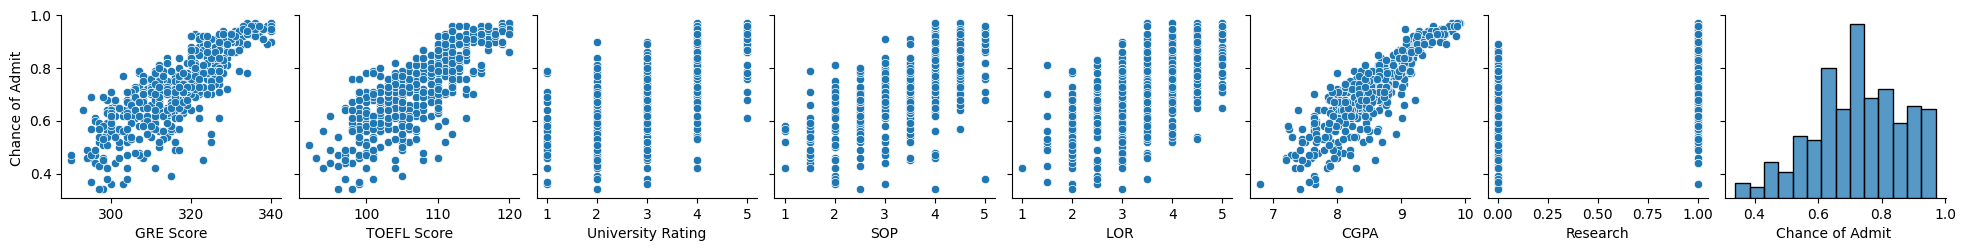

In [ ]:
sns.pairplot(df, y_vars=["Chance of Admit"])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

df_scaled.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1.819238,1.778865,0.775582,1.137360,1.098944,1.776806,0.886405,1.406107
1,0.667148,-0.031601,0.775582,0.632315,1.098944,0.485859,0.886405,0.271349
2,-0.041830,-0.525364,-0.099793,-0.377773,0.017306,-0.954043,0.886405,-0.012340
3,0.489904,0.462163,-0.099793,0.127271,-1.064332,0.154847,0.886405,0.555039
4,-0.219074,-0.689952,-0.975168,-1.387862,-0.523513,-0.606480,-1.128152,-0.508797


differen variable have different range so we are performng standard scaling to compare all features on same scale.

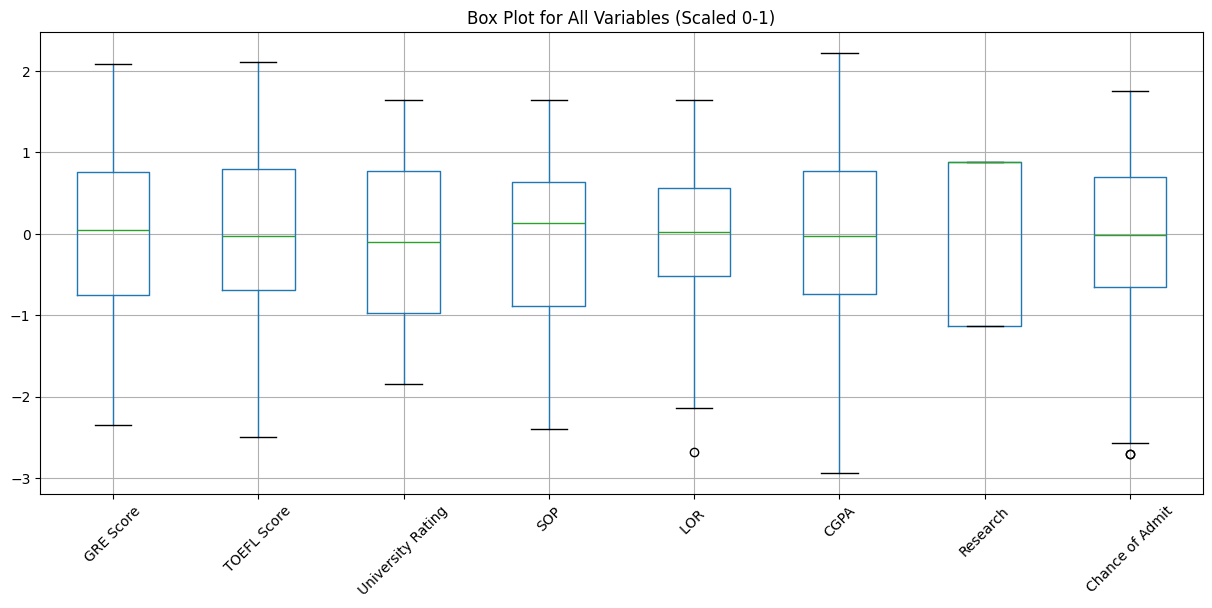

In [ ]:
plt.figure(figsize=(15,6))
df_scaled.boxplot()
plt.xticks(rotation=45)
plt.show()

<Axes: ylabel='LOR '>

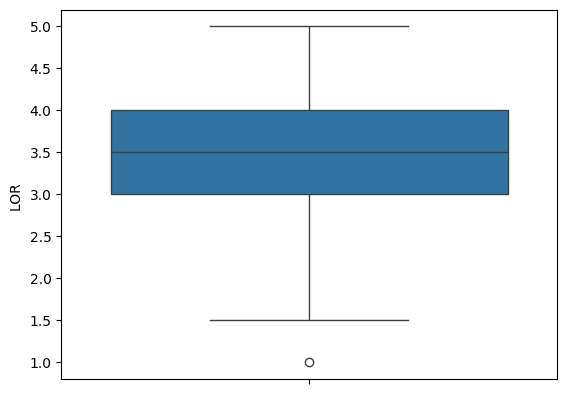

In [ ]:
sns.boxplot(df['LOR '])

In [ ]:
df['LOR '].value_counts()

,count
LOR,
3.0,99
4.0,94
3.5,86
4.5,63
2.5,50
5.0,50
2.0,46
1.5,11
1.0,1


most of distribution of lor is between 1.5 to 5 so 1 here is looking as outlier and there is only 1 data point so lets remove it.

In [ ]:
df = df[df['LOR '] != 1]

<Axes: ylabel='LOR '>

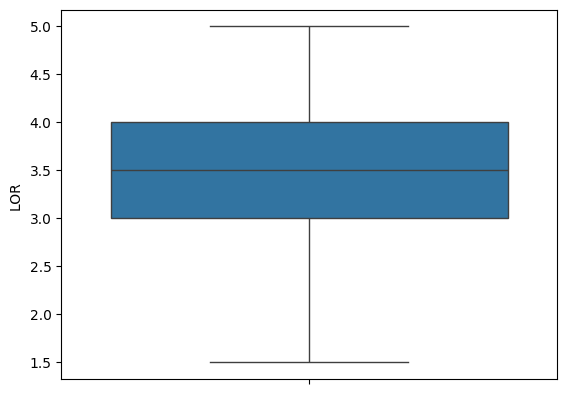

In [ ]:
sns.boxplot(df['LOR '])

In [ ]:
df['chanc']


KeyError: 'chance_of_admit'

# Linear Regression

In [ ]:
y = df_scaled['Chance of Admit']
X = df_scaled.drop('Chance of Admit', axis=1)
y.shape, X.shape

((500,), (500, 7))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
X_train.shape, X_test.shape

((400, 7), (100, 7))

In [ ]:
import statsmodels.api as sm

In [ ]:
x_sm = sm.add_constant(X_train)

In [ ]:
sm_model = sm.OLS(y_train, x_sm).fit()
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:        Chance of Admit   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     257.7
Date:                Fri, 26 Sep 2025   Prob (F-statistic):          2.10e-142
Time:                        13:08:11   Log-Likelihood:                -224.33
No. Observations:                 400   AIC:                             464.7
Df Residuals:                     392   BIC:                             496.6
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0081      0.02

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
vif = pd.DataFrame()
vif['features'] = X_train.columns
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = 'VIF', ascending = False)
vif

,features,VIF
0,GRE Score,4.87
5,CGPA,4.75
1,TOEFL Score,4.24
3,SOP,2.92
2,University Rating,2.80
4,LOR,2.08
6,Research,1.51


all the features have VIF score below 5 which means there is no multicolinearity between independent variables

In [ ]:
y_hat = sm_model.predict(x_sm)
errors = y_hat - y_train

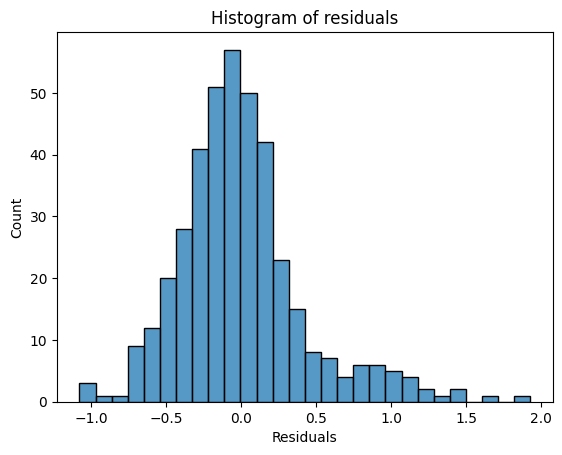

In [ ]:
sns.histplot(errors)
plt.xlabel('Residuals')
plt.title("Histogram of residuals")
plt.show()

Distribution of errors is right skewed.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
model.coef_

array([0.14663037, 0.13676748, 0.04965566, 0.02109985, 0.09459574,
       0.50009953, 0.07002187])

In [ ]:
model.intercept_

np.float64(0.008094500786335137)

In [ ]:
y_hat = model.predict(X_test)

In [ ]:
y_hat

array([-4.82948675e-01, -1.51097174e-01,  1.57638378e+00,  6.82149579e-02,
        6.76967037e-01, -4.01441349e-01,  1.68243452e-01, -5.50176038e-02,
        4.75118088e-01, -4.62430559e-01, -3.75238142e-01, -1.13183961e+00,
        4.28910563e-01,  5.23841381e-01,  3.54107537e-01,  9.64758260e-01,
       -6.56436915e-01,  2.85282065e-01,  1.24643191e+00, -3.54114638e-01,
       -6.61722365e-01,  5.11777214e-01,  8.53023495e-01, -9.19121225e-01,
        4.75344806e-01, -1.08456860e+00,  1.63034876e+00, -5.48742211e-01,
        9.82488804e-01, -7.73931949e-02, -6.26947142e-01,  6.61572016e-01,
       -8.79455266e-01,  1.33844957e+00, -1.51652144e+00,  6.83761148e-01,
       -2.44956642e-01, -6.27915605e-01, -4.40987321e-01,  1.34722847e+00,
       -1.10648015e+00, -4.32290050e-01,  3.58899553e-01,  1.76750969e+00,
        3.55080437e-01, -1.41408109e+00, -3.88338604e-01, -6.48523464e-01,
       -4.83068643e-01, -4.33492397e-01,  7.92840896e-01,  1.39556512e+00,
        1.11016490e+00, -

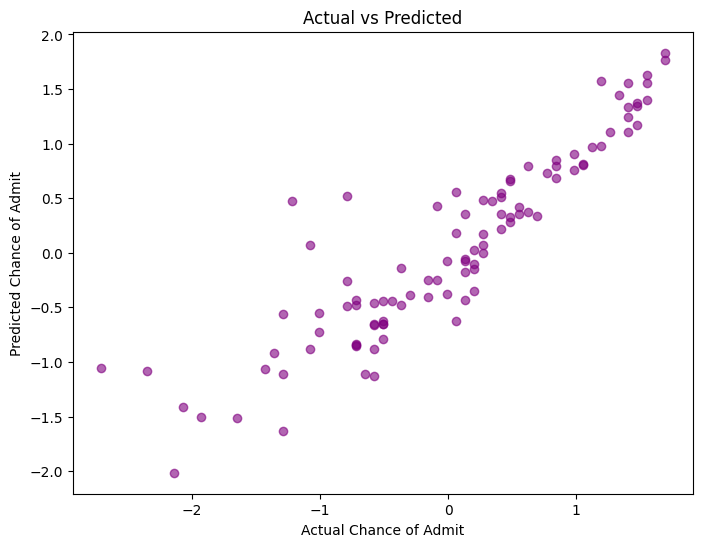

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_hat, color='purple', alpha=0.6)
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Actual vs Predicted")
plt.show()

The model is performing well: predictions align with actual values.    

Stronger accuracy in the medium-to-high chance of admit range, but slightly   weaker in the low range  

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_hat)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.2851093894636916


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_hat)
print("RMSE:", np.sqrt(mse))

RMSE: 0.4171236967003736


In [ ]:
r2 = model.score(X_test, y_test)
print("R2 Score :", r2)

R2 Score : 0.8208741703103732


In [ ]:
n = X_test.shape[0]  # number of observations
p = X_test.shape[1]  # number of features
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R2 Score:", adjusted_r2)

Adjusted R2 Score: 0.8072450310948581


there is not much difference in r2 score and adjusted r2 score which imply our model is reasonable no useless feature we added.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

df_scaled1 = pd.DataFrame(scaled_data, columns=df.columns)

df_scaled1.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,0.94,0.928571,0.75,0.875,0.875,0.913462,1.0,0.920635
1,0.68,0.535714,0.75,0.750,0.875,0.663462,1.0,0.666667
2,0.52,0.428571,0.50,0.500,0.625,0.384615,1.0,0.603175
3,0.64,0.642857,0.50,0.625,0.375,0.599359,1.0,0.730159
4,0.48,0.392857,0.25,0.250,0.500,0.451923,0.0,0.492063


In [ ]:
y = df_scaled1['Chance of Admit']
X = df_scaled1.drop('Chance of Admit', axis=1)
y.shape, X.shape

((500,), (500, 7))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [ ]:
X_train.shape, X_test.shape

((400, 7), (100, 7))

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
model.coef_

array([0.14541621, 0.14106352, 0.03891338, 0.01907985, 0.09159877,
       0.57796411, 0.03157108])

In [ ]:
model.intercept_

np.float64(0.018693219780457793)

In [ ]:
y_hat = model.predict(X_test)

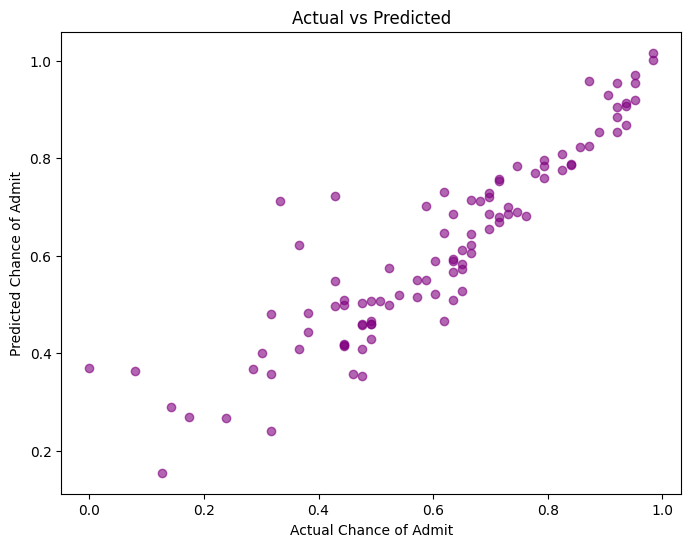

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_hat, color='purple', alpha=0.6)
plt.xlabel("Actual Chance of Admit")
plt.ylabel("Predicted Chance of Admit")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_hat)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 0.06380983143517134


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_hat)
print("RMSE:", np.sqrt(mse))

RMSE: 0.09335572155001222


In [ ]:
r2 = model.score(X_test, y_test)
print("R2 Score :", r2)

R2 Score : 0.8208741703103732


In [ ]:
n = X_test.shape[0]  # number of observations
p = X_test.shape[1]  # number of features
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R2 Score:", adjusted_r2)

Adjusted R2 Score: 0.8072450310948581


by both the kind of scaling its giving same kind ot r2 score so

1. Research Experience Insights:

Students with research experience tend to have a higher Chance of Admit, especially for
applicants with more than 50% probability.
Conclusion: Research experience is an important factor in admission decisions. Students with
research experience have a competitive advantage.

2. Feature Importance  
CGPA, GRE Score, and TOEFL Score show the highest correlation with the target variable
(Chance of Admit).
Conclusion: These variables have the most predictive power, so academic performance and
standardized test scores are crucial.

3. Model Performance   
R-squared = 0.825, Adjusted R-squared = 0.822
Small difference indicates good feature selection and minimal overfitting.
Conclusion: The model explains ~82% of the variance in admission chances, which is strong for
this dataset.

4. Multicollinearity Check   
All VIF scores are below 5.
Conclusion: Independent variables are not highly correlated, which strengthens model reliability.

5. Residual Analysis   
Distribution of residuals is slightly right-skewed, but most errors are close to 0.
Linearity assumption holds.
Heteroskedasticity assumption not perfectly met, but the spread of residuals is mostly
consistent between -0.5 and 0.5.

6. Key Takeaways    
Academic scores (GRE, TOEFL, CGPA) and research experience are strong predictors of
admission chances.
Students without research experience can improve their chances by focusing on strong test
scores and academic performance.
The linear regression model performs well, but slight heteroskedasticity suggests potential for
improvement with models robust to non-constant variance, e.g., weighted regression or tree
based models.
The dataset is small but clean, and features are well-selected.